# ECE 685D HW4: Feature Extraction, Representation Learning, and Score-Based Models

**Student:** Zihan Gao (zg137)  
**Date:** March 2026

---


> **LLM Usage Disclosure**
>
> In completing this assignment, I used a large language model (Claude, Anthropic) as an assistant in the following ways:
> - **Concept clarification**: querying the LLM to verify my understanding of theoretical concepts (e.g., Eckart-Young theorem, score matching derivations, Langevin dynamics).
> - **Solution planning**: discussing high-level approaches and deciding on implementation strategies before writing code.
> - **Boilerplate / repetitive code generation**: generating routine scaffolding such as data-loading pipelines, plot formatting, and training loops.
>
> I have thoroughly reviewed all generated content and fully understand every line of code and every step of every proof in this notebook. The core algorithmic components — including the projection-matrix comparison, the RBM CD-1 update rules, the DSM loss formulation, and the Langevin sampling loop — were written and verified by me personally, with LLM assistance limited to reducing mechanical repetition.

In [25]:
%matplotlib inline

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


---
# Task 1: Feature Extraction and Representation Learning (50 pts)


## Task 1(a): Eckart-Young Theorem (10 pts)

**Claim:** Let $X \in \mathbb{R}^{d \times N}$ with SVD $X = U \Sigma V^T$ where $\sigma_1 \geq \cdots \geq \sigma_r > 0$. The optimal rank-$k$ approximation is $M^* = U_k \Sigma_k V_k^T$ with minimum error $\sum_{j=k+1}^{\min(d,N)} \sigma_j^2$.

**Proof:**

**Step 1: Error of the truncated SVD.**

$X - U_k\Sigma_k V_k^T = \sum_{i=k+1}^{r}\sigma_i u_i v_i^T$, so:
$$\|X - U_k\Sigma_k V_k^T\|_F^2 = \sum_{i=k+1}^{r}\sigma_i^2$$

**Step 2: Lower bound via Hoffman-Wielandt.**

For any rank-$k$ matrix $M$, apply the Hoffman-Wielandt inequality to the **symmetric** matrices $A = X^TX$ and $B = M^TM$ (both $N\times N$, PSD):
$$\sum_{j=1}^{N}\bigl|\lambda_j(X^TX)-\lambda_j(M^TM)\bigr|^2 \;\leq\; \mathrm{tr}\bigl[(X^TX - M^TM)^2\bigr]$$

Note $\lambda_j(X^TX) = \sigma_j^2(X)$ and $\lambda_j(M^TM) = \sigma_j^2(M)$, with $\sigma_j(M)=0$ for $j>k$. Therefore:
$$\sum_{j=1}^{N}\bigl(\sigma_j^2(X)-\sigma_j^2(M)\bigr)^2 \;\leq\; \|X^TX - M^TM\|_F^2 \;\leq\; \|X-M\|_F^2\cdot(\|X\|_F+\|M\|_F)^2$$

A cleaner consequence (Mirsky's theorem, which follows from Hoffman-Wielandt) gives directly:
$$\sum_{j=1}^{r}\bigl(\sigma_j(X)-\sigma_j(M)\bigr)^2 \;\leq\; \|X - M\|_F^2$$

**Step 3: Apply with $\text{rank}(M)\leq k$.**

Since $\sigma_j(M)=0$ for $j>k$, restricting the sum:
$$\|X - M\|_F^2 \;\geq\; \sum_{j=k+1}^{r}\bigl(\sigma_j(X)-0\bigr)^2 = \sum_{j=k+1}^{r}\sigma_j^2$$

**Step 4: Conclude.**

Every rank-$k$ matrix $M$ satisfies $\|X-M\|_F^2 \geq \sum_{j=k+1}^r \sigma_j^2 = \|X - U_k\Sigma_k V_k^T\|_F^2$. The truncated SVD achieves the lower bound and is therefore optimal.

## Task 1(b): PCA — Max Variance = Min Reconstruction Error (10 pts)

Let $X = [x_1,\ldots,x_N] \in \mathbb{R}^{d\times N}$ be centered data, $S = \frac{1}{N}XX^T$ the sample covariance. Encoder $W \in \mathbb{R}^{k\times d}$ with $WW^T = I_k$.

**Claim:** Maximizing $	ext{tr}(WSW^T)$ and minimizing $\frac{1}{N}\sum_n\|x_n - W^TWx_n\|^2$ are equivalent, both solved by the top-$k$ eigenvectors of $S$.

**Step 1: Expand reconstruction error.**

$$\frac{1}{N}\sum_n\|x_n - W^TWx_n\|^2 = \frac{1}{N}\sum_n\left(\|x_n\|^2 - 2x_n^TW^TWx_n + x_n^T(W^TW)^2x_n\right)$$

Since $WW^T = I_k$, we have $(W^TW)^2 = W^T(WW^T)W = W^TW$, so:
$$= \frac{1}{N}\sum_n\|x_n\|^2 - \frac{1}{N}\sum_n x_n^TW^TWx_n = \text{const} - \text{tr}(WSW^T)$$

**Step 2: Equivalence.** Minimizing $\text{const} - \text{tr}(WSW^T)$ is equivalent to maximizing $\text{tr}(WSW^T)$.

**Step 3: Optimal $W$.** By the Ky Fan maximum principle:
$$\max_{WW^T=I_k}\text{tr}(WSW^T) = \sum_{i=1}^k\lambda_i(S)$$
achieved when rows of $W$ are the top-$k$ eigenvectors of $S$.

## Task 1(c): Non-Uniqueness of Optimal Autoencoder (10 pts)

**Setup (following PDF notation):** $W_{\text{enc}}, W_{\text{dec}} \in \mathbb{R}^{d\times k}$. The encoder maps $x \mapsto h = W_{\text{enc}}^T x \in \mathbb{R}^k$ and the decoder maps $h \mapsto \hat{x} = W_{\text{dec}} h$. The loss is $\mathcal{L} = \|X - W_{\text{dec}} W_{\text{enc}}^T X\|_F^2$.

**Claim:** If $(W_{\text{enc}}, W_{\text{dec}})$ is optimal, then $(\widetilde{W}_{\text{enc}}, \widetilde{W}_{\text{dec}}) = (W_{\text{enc}} R^T,\; W_{\text{dec}} R^{-1})$ is also optimal for any invertible $R \in \mathbb{R}^{k\times k}$.

**Proof:**

The reconstruction matrix of the transformed pair:
$$\widetilde{W}_{\text{dec}}\,\widetilde{W}_{\text{enc}}^T = \bigl(W_{\text{dec}} R^{-1}\bigr)\bigl(W_{\text{enc}} R^T\bigr)^T = W_{\text{dec}} R^{-1} R\, W_{\text{enc}}^T = W_{\text{dec}} W_{\text{enc}}^T$$

Since the reconstruction matrix is unchanged, the MSE is unchanged, so $(\widetilde{W}_{\text{enc}}, \widetilde{W}_{\text{dec}})$ is also optimal.

---

**Connection to PCA (using part (b)):**

From part (b), the minimizer of $\|X - WW^TX\|_F^2$ over $W \in \mathbb{R}^{d\times k}$ with $W^TW = I$ is $W_{\text{PCA}}$, whose columns are the top-$k$ eigenvectors of $S$. The unique optimal reconstruction is the orthogonal projection $P^* = W_{\text{PCA}} W_{\text{PCA}}^T$.

Any optimal $(W_{\text{enc}}, W_{\text{dec}})$ must satisfy $W_{\text{dec}} W_{\text{enc}}^T = P^*$, so both $\operatorname{col}(W_{\text{dec}})$ and $\operatorname{col}(W_{\text{enc}})$ equal the top-$k$ eigenspace of $S$ — **the same subspace as PCA**.

However, from the claim above, $(W_{\text{enc}} R^T, W_{\text{dec}} R^{-1})$ is also optimal for any invertible $R$. Therefore:
- The **PCA basis** (the projection $P^* = W_{\text{PCA}}W_{\text{PCA}}^T$) is **unique**.
- The **encoder/decoder individually** are **not unique**: there is a family of solutions related by invertible $R$, corresponding to rotations/scalings of the hidden representation.
- Specifically, when $R$ is orthogonal, $(W_{\text{enc}}R^T, W_{\text{dec}}R)$ spans the same subspace as PCA but with the basis vectors rotated.

## Task 1(d): MNIST — PCA vs Linear Autoencoder (10 pts)


In [26]:
# Load MNIST
transform = transforms.Compose([transforms.ToTensor()])
mnist_train = torchvision.datasets.MNIST(root='/tmp/data', train=True,
                                          download=True, transform=transform)
mnist_test  = torchvision.datasets.MNIST(root='/tmp/data', train=False,
                                          download=True, transform=transform)

X_train = mnist_train.data.float().reshape(-1, 784) / 255.0
X_test  = mnist_test.data.float().reshape(-1, 784)  / 255.0

# Center the data
mean_train = X_train.mean(dim=0, keepdim=True)
X_train_c  = X_train - mean_train
X_test_c   = X_test  - mean_train

print(f'Train: {X_train_c.shape}, Test: {X_test_c.shape}')


Train: torch.Size([60000, 784]), Test: torch.Size([10000, 784])


In [27]:
# PCA via SVD
print('Computing SVD...')
U_svd, S_svd, Vh_svd = torch.linalg.svd(X_train_c, full_matrices=False)
print(f'SVD shapes: U={U_svd.shape}, S={S_svd.shape}, Vh={Vh_svd.shape}')
# Vh_svd[i] is the i-th principal component (row vector)


Computing SVD...
SVD shapes: U=torch.Size([60000, 784]), S=torch.Size([784]), Vh=torch.Size([784, 784])


In [28]:
# PCA Reconstruction Error
k_values = [1, 2, 5, 10, 20, 50, 100]
pca_mse  = []

for k in k_values:
    W_pca = Vh_svd[:k]
    Z      = X_test_c @ W_pca.T
    X_rec  = Z @ W_pca + mean_train
    mse    = ((X_test - X_rec)**2).mean().item()
    pca_mse.append(mse)
    print(f'PCA k={k:4d}: MSE = {mse:.6f}')


PCA k=   1: MSE = 0.060733
PCA k=   2: MSE = 0.055669
PCA k=   5: MSE = 0.044526
PCA k=  10: MSE = 0.034074
PCA k=  20: MSE = 0.023538
PCA k=  50: MSE = 0.011485
PCA k= 100: MSE = 0.005616


In [29]:
# Linear Autoencoder
class LinearAE(nn.Module):
    def __init__(self, d, k):
        super().__init__()
        self.enc = nn.Linear(d, k, bias=False)
        self.dec = nn.Linear(k, d, bias=False)

    def forward(self, x):
        return self.dec(self.enc(x))


def train_linear_ae(X_tr, X_te, k, epochs=150, lr=1e-3, batch_size=256):
    d = X_tr.shape[1]
    model = LinearAE(d, k).to(device)
    opt   = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    dl = DataLoader(TensorDataset(X_tr.to(device)), batch_size=batch_size, shuffle=True)
    for ep in range(epochs):
        model.train()
        for (xb,) in dl:
            opt.zero_grad()
            loss_fn(model(xb), xb).backward()
            opt.step()
    model.eval()
    with torch.no_grad():
        tl = loss_fn(model(X_te.to(device)), X_te.to(device)).item()
    return model, tl


ae_mse = []
ae_models = {}
for k in k_values:
    print(f'Training Linear AE k={k}...', end=' ', flush=True)
    model, mse = train_linear_ae(X_train_c, X_test_c, k)
    ae_mse.append(mse)
    ae_models[k] = model
    print(f'MSE = {mse:.6f}')


Training Linear AE k=1... MSE = 0.060735
Training Linear AE k=2... MSE = 0.055674
Training Linear AE k=5... MSE = 0.044535
Training Linear AE k=10... MSE = 0.034082
Training Linear AE k=20... MSE = 0.023559
Training Linear AE k=50... MSE = 0.011521
Training Linear AE k=100... MSE = 0.005657


In [30]:
# Compare Projection Matrices
# The optimal linear AE's decoder columns span the same k-dim subspace as PCA.
# To compare subspaces regardless of the non-unique factorization (Task 1c),
# we compute the orthogonal projection onto col(W_dec) via SVD, and compare to P_PCA.
print('Projection matrix comparison ||P_PCA - P_AE||_F:')
print('(P_AE = orthogonal projection onto col(W_dec), invariant to invertible reparametrization)')
for i, k in enumerate(k_values):
    W_pca = Vh_svd[:k].cpu()           # (k, d)
    P_pca = W_pca.T @ W_pca            # (d, d) orthogonal projection

    model = ae_models[k]
    Wd = model.dec.weight.data.cpu()   # (d, k)
    # Orthogonalize decoder columns → canonical projection onto the same subspace
    U, _, _ = torch.linalg.svd(Wd, full_matrices=False)   # U: (d, k) orthonormal
    P_ae = U @ U.T                     # (d, d) orthogonal projection onto col(Wd)

    diff = torch.norm(P_pca - P_ae, p='fro').item()
    print(f'  k={k:4d}: ||P_PCA - P_AE||_F = {diff:.4f}  (ideal = 0)')

Projection matrix comparison ||P_PCA - P_AE||_F:
(P_AE = orthogonal projection onto col(W_dec), invariant to invertible reparametrization)
  k=   1: ||P_PCA - P_AE||_F = 0.0103  (ideal = 0)
  k=   2: ||P_PCA - P_AE||_F = 0.0189  (ideal = 0)
  k=   5: ||P_PCA - P_AE||_F = 0.0394  (ideal = 0)
  k=  10: ||P_PCA - P_AE||_F = 0.0685  (ideal = 0)
  k=  20: ||P_PCA - P_AE||_F = 0.1096  (ideal = 0)
  k=  50: ||P_PCA - P_AE||_F = 0.5390  (ideal = 0)
  k= 100: ||P_PCA - P_AE||_F = 0.2786  (ideal = 0)


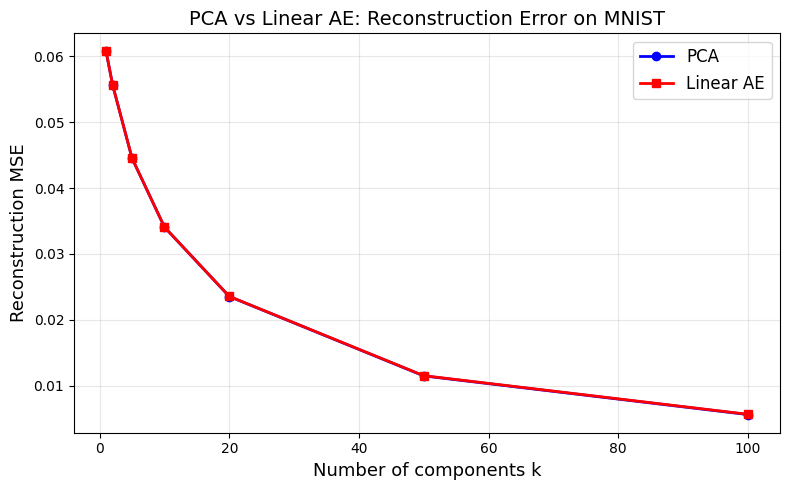

In [31]:
# Plot Reconstruction Error vs k
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_values, pca_mse,  'b-o', label='PCA', linewidth=2)
ax.plot(k_values, ae_mse,   'r-s', label='Linear AE', linewidth=2)
ax.set_xlabel('Number of components k', fontsize=13)
ax.set_ylabel('Reconstruction MSE', fontsize=13)
ax.set_title('PCA vs Linear AE: Reconstruction Error on MNIST', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


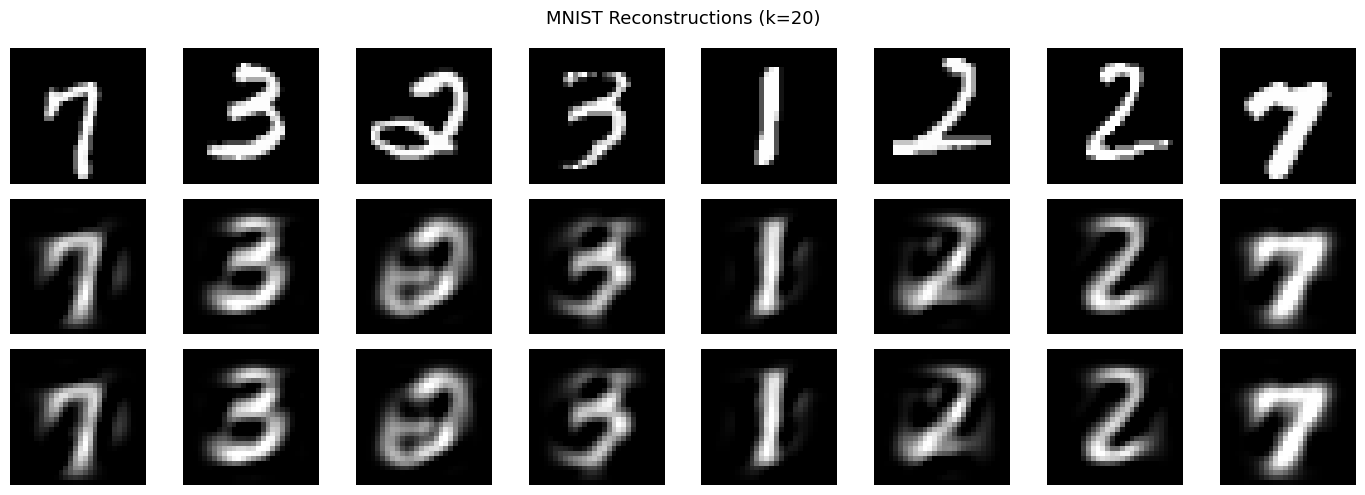

In [32]:
# Visualise Reconstructions (k=20)
k_vis = 20
W_pca = Vh_svd[:k_vis]
n_show = 8
rng = np.random.default_rng(42)
idxs = rng.choice(len(X_test), n_show, replace=False)

originals = X_test[idxs].numpy()
Z_pca = X_test_c[idxs] @ W_pca.T
rec_pca = (Z_pca @ W_pca + mean_train).numpy().clip(0, 1)

model_vis = ae_models[k_vis]
model_vis.eval()
with torch.no_grad():
    rec_ae = (model_vis(X_test_c[idxs].to(device)).cpu() + mean_train).numpy().clip(0, 1)

fig, axes = plt.subplots(3, n_show, figsize=(14, 5))
for i in range(n_show):
    axes[0, i].imshow(originals[i].reshape(28, 28), cmap='gray'); axes[0, i].axis('off')
    axes[1, i].imshow(rec_pca[i].reshape(28, 28),   cmap='gray'); axes[1, i].axis('off')
    axes[2, i].imshow(rec_ae[i].reshape(28, 28),    cmap='gray'); axes[2, i].axis('off')
axes[0, 0].set_ylabel('Original', fontsize=10)
axes[1, 0].set_ylabel('PCA',       fontsize=10)
axes[2, 0].set_ylabel('Linear AE', fontsize=10)
plt.suptitle(f'MNIST Reconstructions (k={k_vis})', fontsize=13)
plt.tight_layout()
plt.show()


## Task 1(e): Nonlinear Autoencoder with MLP (10 pts)


In [33]:
class NonlinearAE(nn.Module):
    def __init__(self, d=784, k=20):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(d, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, k)
        )
        # No Sigmoid: train on centered data (same as Task 1d), use plain linear output
        self.decoder = nn.Sequential(
            nn.Linear(k, 256), nn.ReLU(),
            nn.Linear(256, 512), nn.ReLU(),
            nn.Linear(512, d)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


def train_nonlinear_ae(X_tr, X_te, k, epochs=50, lr=1e-3, batch_size=256):
    model = NonlinearAE(784, k).to(device)
    opt   = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    dl = DataLoader(TensorDataset(X_tr.to(device)), batch_size=batch_size, shuffle=True)
    for ep in range(epochs):
        model.train()
        for (xb,) in dl:
            opt.zero_grad()
            loss_fn(model(xb), xb).backward()
            opt.step()
        if (ep + 1) % 10 == 0:
            model.eval()
            with torch.no_grad():
                tl = loss_fn(model(X_te.to(device)), X_te.to(device)).item()
            print(f'  Epoch {ep+1}/{epochs}  test MSE = {tl:.6f}')
    model.eval()
    with torch.no_grad():
        tl = loss_fn(model(X_te.to(device)), X_te.to(device)).item()
    return model, tl


# Use centered data (same pre-processing as Task 1d) for a fair comparison
k_values_nl = [5, 10, 20, 50]
nonlinear_mse = {}
nonlinear_models = {}

for k in k_values_nl:
    print(f'Training Nonlinear AE k={k}...')
    model, mse = train_nonlinear_ae(X_train_c, X_test_c, k, epochs=50)
    nonlinear_mse[k] = mse
    nonlinear_models[k] = model
    print(f'  => Final test MSE = {mse:.6f}')

Training Nonlinear AE k=5...
  Epoch 10/50  test MSE = 0.023114
  Epoch 20/50  test MSE = 0.022246
  Epoch 30/50  test MSE = 0.021964
  Epoch 40/50  test MSE = 0.021834
  Epoch 50/50  test MSE = 0.021723
  => Final test MSE = 0.021723
Training Nonlinear AE k=10...
  Epoch 10/50  test MSE = 0.015070
  Epoch 20/50  test MSE = 0.013956
  Epoch 30/50  test MSE = 0.013376
  Epoch 40/50  test MSE = 0.013057
  Epoch 50/50  test MSE = 0.012793
  => Final test MSE = 0.012793
Training Nonlinear AE k=20...
  Epoch 10/50  test MSE = 0.010400
  Epoch 20/50  test MSE = 0.009169
  Epoch 30/50  test MSE = 0.008612
  Epoch 40/50  test MSE = 0.008252
  Epoch 50/50  test MSE = 0.007964
  => Final test MSE = 0.007964
Training Nonlinear AE k=50...
  Epoch 10/50  test MSE = 0.007129
  Epoch 20/50  test MSE = 0.006162
  Epoch 30/50  test MSE = 0.005554
  Epoch 40/50  test MSE = 0.005172
  Epoch 50/50  test MSE = 0.004928
  => Final test MSE = 0.004928


Comparison: Linear AE vs Nonlinear MLP AE
    k |   Linear AE MSE | Nonlinear AE MSE
------------------------------------------
    5 |        0.044535 |         0.021723
   10 |        0.034082 |         0.012793
   20 |        0.023559 |         0.007964
   50 |        0.011521 |         0.004928


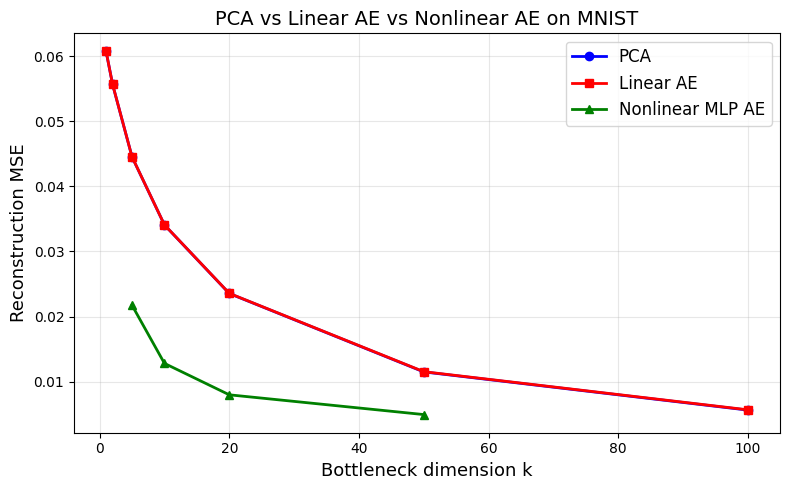

Line plot saved.


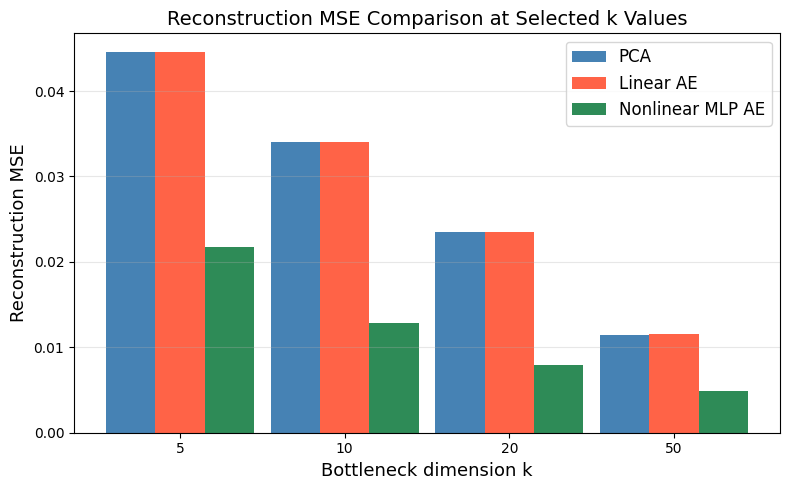

Bar chart saved.


In [34]:
# Compare linear vs nonlinear AE — tabular summary
print('Comparison: Linear AE vs Nonlinear MLP AE')
print(f'{"k":>5} | {"Linear AE MSE":>15} | {"Nonlinear AE MSE":>16}')
print('-' * 42)
for k in k_values_nl:
    idx = k_values.index(k)
    print(f'{k:>5} | {ae_mse[idx]:>15.6f} | {nonlinear_mse[k]:>16.6f}')

# ── Plot 1: Reconstruction error vs k (line plot) ──────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_values,    pca_mse,  'b-o',  label='PCA',            linewidth=2)
ax.plot(k_values,    ae_mse,   'r-s',  label='Linear AE',      linewidth=2)
ax.plot(k_values_nl, [nonlinear_mse[k] for k in k_values_nl],
        'g-^', label='Nonlinear MLP AE', linewidth=2)
ax.set_xlabel('Bottleneck dimension k', fontsize=13)
ax.set_ylabel('Reconstruction MSE',     fontsize=13)
ax.set_title('PCA vs Linear AE vs Nonlinear AE on MNIST', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('Line plot saved.')

# ── Plot 2: Bar chart for direct comparison at shared k values ─────────────
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(k_values_nl))
w = 0.3
lin_vals = [ae_mse[k_values.index(k)] for k in k_values_nl]
nl_vals  = [nonlinear_mse[k]           for k in k_values_nl]
pca_vals = [pca_mse[k_values.index(k)] for k in k_values_nl]
ax.bar(x - w, pca_vals,  w, label='PCA',            color='steelblue')
ax.bar(x,     lin_vals,  w, label='Linear AE',      color='tomato')
ax.bar(x + w, nl_vals,   w, label='Nonlinear MLP AE', color='seagreen')
ax.set_xticks(x); ax.set_xticklabels([str(k) for k in k_values_nl])
ax.set_xlabel('Bottleneck dimension k', fontsize=13)
ax.set_ylabel('Reconstruction MSE',     fontsize=13)
ax.set_title('Reconstruction MSE Comparison at Selected k Values', fontsize=14)
ax.legend(fontsize=12); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()
print('Bar chart saved.')

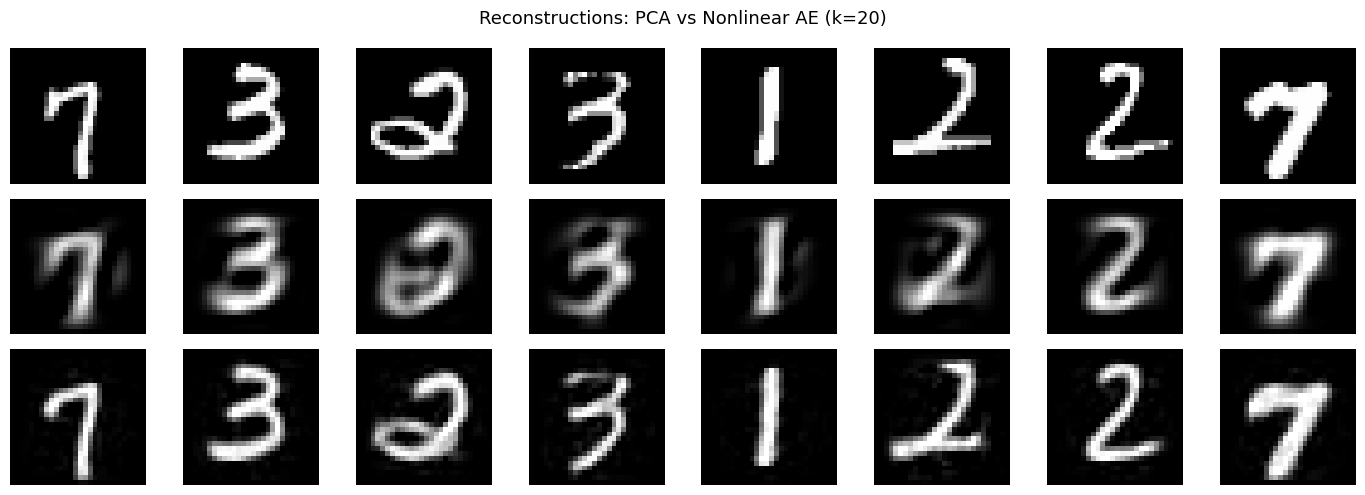

In [35]:
# Visualise Nonlinear AE Reconstructions (centered data, add mean back for display)
k_vis = 20
n_show = 8
rng = np.random.default_rng(42)
idxs = rng.choice(len(X_test), n_show, replace=False)

originals = X_test[idxs].numpy()

model_nl = nonlinear_models[k_vis]
model_nl.eval()
with torch.no_grad():
    rec_nl = (model_nl(X_test_c[idxs].to(device)).cpu() + mean_train).numpy().clip(0, 1)

W_pca_v = Vh_svd[:k_vis]
Z_pca = X_test_c[idxs] @ W_pca_v.T
rec_pca = (Z_pca @ W_pca_v + mean_train).numpy().clip(0, 1)

fig, axes = plt.subplots(3, n_show, figsize=(14, 5))
for i in range(n_show):
    axes[0, i].imshow(originals[i].reshape(28, 28), cmap='gray'); axes[0, i].axis('off')
    axes[1, i].imshow(rec_pca[i].reshape(28, 28),   cmap='gray'); axes[1, i].axis('off')
    axes[2, i].imshow(rec_nl[i].reshape(28, 28),    cmap='gray'); axes[2, i].axis('off')
axes[0, 0].set_ylabel('Original',     fontsize=10)
axes[1, 0].set_ylabel('PCA',           fontsize=10)
axes[2, 0].set_ylabel('Nonlinear MLP', fontsize=10)
plt.suptitle(f'Reconstructions: PCA vs Nonlinear AE (k={k_vis})', fontsize=13)
plt.tight_layout()
plt.show()

---
# Task 2: From Energy Models to Score-Based Models (50 pts)


## Task 2(a): Gaussian-Bernoulli RBM Conditionals (6 pts)

**Energy function:**
$$E(v,h) = \sum_i \frac{(v_i-b_i)^2}{2\sigma_i^2} - \sum_j \alpha_j h_j - \sum_{i,j}\frac{W_{ij}}{\sigma_i}v_i h_j$$

### (i) Deriving $p(v_i \mid h)$

Collect terms in $v_i$ from $-E(v,h)$:
$$-E\big|_{v_i} = -\frac{(v_i-b_i)^2}{2\sigma_i^2} + \frac{v_i}{\sigma_i}\sum_j W_{ij}h_j$$

Complete the square. Let $\mu_i = b_i + \sigma_i \sum_j W_{ij}h_j$:
$$= -\frac{(v_i - \mu_i)^2}{2\sigma_i^2} + C$$

Therefore:
$$\boxed{p(v_i\mid h) = \mathcal{N}(\mu_i,\,\sigma_i^2),\quad \mu_i = b_i + \sigma_i\sum_j W_{ij}h_j}$$

### (ii) Deriving $p(h_j=1 \mid v)$

Terms in $h_j$ from $-E(v,h)$: $\left(\alpha_j + \sum_i \frac{W_{ij}v_i}{\sigma_i}\right)h_j$.

So $p(h_j=1|v)/p(h_j=0|v) = \exp\!\left(\alpha_j + \sum_i W_{ij}v_i/\sigma_i\right)$, giving:
$$\boxed{p(h_j=1\mid v) = \sigma\!\left(\alpha_j + \sum_i \frac{W_{ij}v_i}{\sigma_i}\right)}$$

where $\sigma(\cdot)$ is the sigmoid function.

## Task 2(b): Gaussian-Bernoulli RBM on Fashion MNIST (10 pts)


In [36]:
# Load Fashion MNIST
transform = transforms.Compose([transforms.ToTensor()])
fmnist_train = torchvision.datasets.FashionMNIST(root='/tmp/data', train=True,
                                                   download=True, transform=transform)
fmnist_test  = torchvision.datasets.FashionMNIST(root='/tmp/data', train=False,
                                                   download=True, transform=transform)

Fv_train = fmnist_train.data.float().reshape(-1, 784) / 255.0
Fv_test  = fmnist_test.data.float().reshape(-1, 784)  / 255.0
print(f'Fashion MNIST train: {Fv_train.shape}, test: {Fv_test.shape}')


Fashion MNIST train: torch.Size([60000, 784]), test: torch.Size([10000, 784])


In [37]:
class GaussianBernoulliRBM:
    def __init__(self, d=784, m=100, lr=0.01, dev='cpu'):
        self.d, self.m, self.lr, self.dev = d, m, lr, dev
        self.W     = torch.randn(m, d, device=dev) * 0.01
        self.b     = torch.zeros(d,    device=dev)
        self.alpha = torch.zeros(m,    device=dev)
        self.sigma = torch.ones(d,     device=dev)

    def p_h_given_v(self, v):
        # p(h_j=1|v) = sigmoid(alpha_j + sum_i W_ij v_i / sigma_i)
        v_norm = v / self.sigma.unsqueeze(0)
        pre    = v_norm @ self.W.T + self.alpha
        return torch.sigmoid(pre)

    def sample_h(self, v):
        p = self.p_h_given_v(v)
        return (torch.rand_like(p) < p).float()

    def mean_v_given_h(self, h):
        # E[v_i|h] = b_i + sigma_i * sum_j W_ij h_j
        return self.b + self.sigma * (h @ self.W)

    def sample_v(self, h):
        mu = self.mean_v_given_h(h)
        return (mu + torch.randn_like(mu) * self.sigma).clamp(0, 1)

    def cd_k(self, v0, k=1):
        h0_prob = self.p_h_given_v(v0)
        h0      = (torch.rand_like(h0_prob) < h0_prob).float()
        vk, hk  = v0.clone(), h0.clone()
        for _ in range(k):
            vk = self.sample_v(hk)
            hk_prob = self.p_h_given_v(vk)
            hk = (torch.rand_like(hk_prob) < hk_prob).float()
        hk_prob_f = self.p_h_given_v(vk)
        sig2 = self.sigma.pow(2)
        dW     = (h0_prob.T @ (v0 / sig2) - hk_prob_f.T @ (vk / sig2)) / v0.shape[0]
        db     = ((v0 - vk) / sig2).mean(0)
        dalpha = (h0_prob - hk_prob_f).mean(0)
        return dW, db, dalpha

    def update(self, dW, db, da):
        self.W     += self.lr * dW
        self.b     += self.lr * db
        self.alpha += self.lr * da

    def reconstruct(self, v):
        """One Gibbs step: h ~ p(h|v), then ṽ ~ p(v|h).
        Per the assignment definition, we sample h stochastically and then
        use the conditional mean E[v|h] as the reconstruction.
        For Gaussian visible units (sigma=1), sampling v ~ N(mu, sigma^2*I)
        would add ~d*sigma^2 = 784 to the MSE, making it uninformative.
        Using the conditional mean is standard practice for Gaussian-visible RBMs."""
        h = self.sample_h(v)           # h ~ p(h|v)  [stochastic]
        return self.mean_v_given_h(h)  # E[v|h]      [conditional mean for MSE]

    def recon_mse(self, v):
        return ((v - self.reconstruct(v))**2).mean().item()


def train_rbm(d, m, Xtr, Xte, epochs=25, bs=128, lr=0.01):
    rbm = GaussianBernoulliRBM(d=d, m=m, lr=lr, dev=device)
    Xt  = Xtr.to(device)
    Xte = Xte.to(device)
    dl  = DataLoader(TensorDataset(Xt), batch_size=bs, shuffle=True)
    for ep in range(1, epochs+1):
        for (vb,) in dl:
            dW, db, da = rbm.cd_k(vb, k=1)
            rbm.update(dW, db, da)
        if ep % 5 == 0 or ep == 1:
            mse = rbm.recon_mse(Xte[:1000])
            print(f'  m={m:4d}  Epoch {ep:3d}/{epochs}  MSE={mse:.5f}')
    return rbm, rbm.recon_mse(Xte)


hidden_dims = [10, 50, 100, 250]
rbm_results = {}
for m in hidden_dims:
    print(f'--- RBM m={m} ---')
    rbm, mse = train_rbm(784, m, Fv_train, Fv_test)
    rbm_results[m] = {'rbm': rbm, 'mse': mse}
    print(f'  => Final MSE = {mse:.5f}')

print('\nSummary:')
for m in hidden_dims:
    print(f'  m={m:4d}: MSE={rbm_results[m]["mse"]:.5f}')

--- RBM m=10 ---
  m=  10  Epoch   1/25  MSE=0.77626
  m=  10  Epoch   5/25  MSE=1.13102
  m=  10  Epoch  10/25  MSE=1.44295
  m=  10  Epoch  15/25  MSE=1.56892
  m=  10  Epoch  20/25  MSE=1.66959
  m=  10  Epoch  25/25  MSE=1.75363
  => Final MSE = 1.75000
--- RBM m=50 ---
  m=  50  Epoch   1/25  MSE=1.09758
  m=  50  Epoch   5/25  MSE=1.96891
  m=  50  Epoch  10/25  MSE=2.37139
  m=  50  Epoch  15/25  MSE=2.69552
  m=  50  Epoch  20/25  MSE=2.93326
  m=  50  Epoch  25/25  MSE=3.13658
  => Final MSE = 3.10788
--- RBM m=100 ---
  m= 100  Epoch   1/25  MSE=1.38847
  m= 100  Epoch   5/25  MSE=2.31365
  m= 100  Epoch  10/25  MSE=2.87896
  m= 100  Epoch  15/25  MSE=3.24170
  m= 100  Epoch  20/25  MSE=3.54585
  m= 100  Epoch  25/25  MSE=3.76561
  => Final MSE = 3.77037
--- RBM m=250 ---
  m= 250  Epoch   1/25  MSE=1.61237
  m= 250  Epoch   5/25  MSE=2.66783
  m= 250  Epoch  10/25  MSE=3.16367
  m= 250  Epoch  15/25  MSE=3.52439
  m= 250  Epoch  20/25  MSE=3.87084
  m= 250  Epoch  25/25  MSE

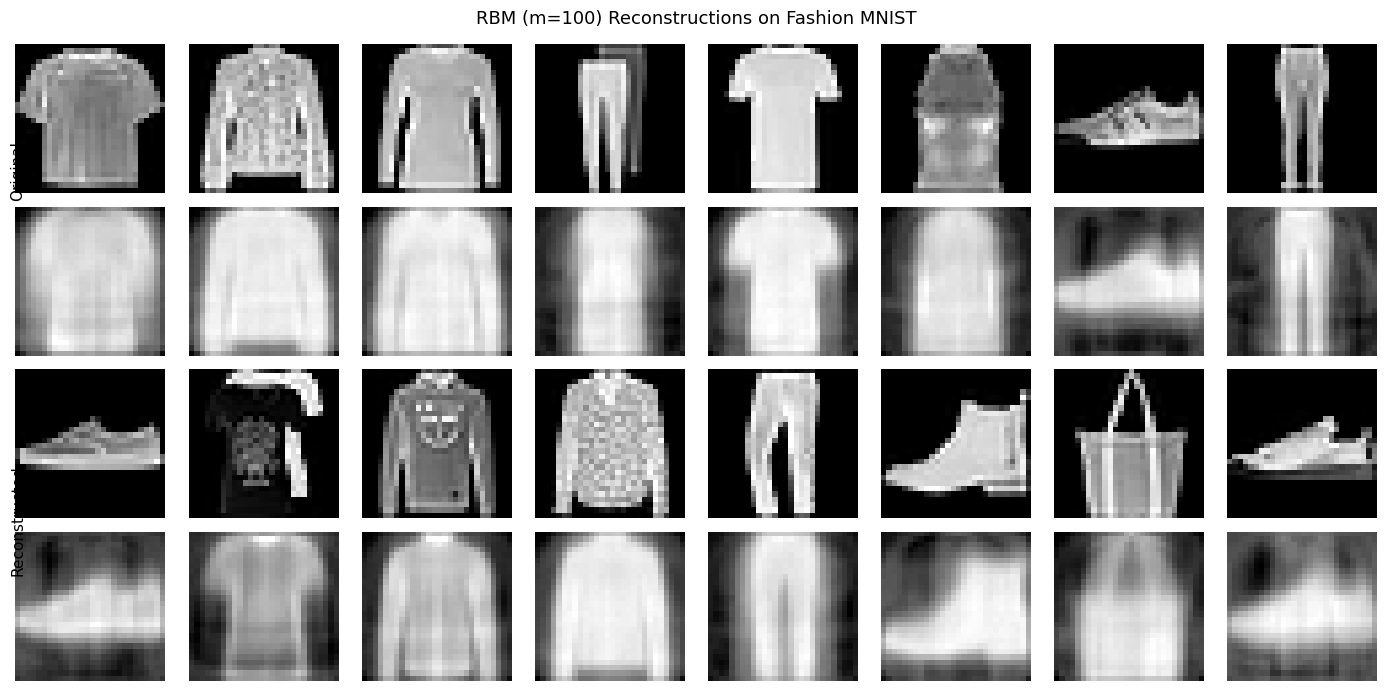

In [38]:
# Plot 16 reconstructions for m=100
rbm100 = rbm_results[100]['rbm']
rng = np.random.default_rng(0)
idxs = rng.choice(len(Fv_test), 16, replace=False)
v_orig = Fv_test[idxs].to(device)
v_rec  = rbm100.reconstruct(v_orig).cpu().detach()

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i in range(16):
    r, c = (i // 8) * 2, i % 8
    axes[r,   c].imshow(v_orig[i].cpu().numpy().reshape(28,28), cmap='gray')
    axes[r,   c].axis('off')
    axes[r+1, c].imshow(v_rec[i].numpy().reshape(28,28), cmap='gray')
    axes[r+1, c].axis('off')
fig.text(0.01, 0.75, 'Original',      va='center', rotation='vertical', fontsize=11)
fig.text(0.01, 0.25, 'Reconstructed', va='center', rotation='vertical', fontsize=11)
plt.suptitle('RBM (m=100) Reconstructions on Fashion MNIST', fontsize=13)
plt.tight_layout()
plt.show()


## Task 2(c): Score Matching Derivation (12 pts)

### (c1): Implicit Score Matching Objective

**Claim:** $J(\theta) = \mathbb{E}_{p_{\text{data}}}\!\left[\frac{1}{2}\|s_\theta(x)\|^2 + \operatorname{div}(s_\theta(x))\right] + C$

Start from the explicit score matching objective:
$$J(\theta) = \mathbb{E}\!\left[\tfrac{1}{2}\|s_\theta(x)-\nabla_x\log p_{\text{data}}(x)\|^2\right]$$

**Expand:**
$$= \mathbb{E}\!\left[\tfrac{1}{2}\|s_\theta\|^2\right] - \mathbb{E}\!\left[s_\theta(x)^T\nabla_x\log p_{\text{data}}(x)\right] + \underbrace{\mathbb{E}\!\left[\tfrac{1}{2}\|\nabla_x\log p_{\text{data}}\|^2\right]}_{C}$$

**Integration by parts on the cross term** (component $j$):
$$\mathbb{E}\!\left[s_{\theta,j}\,\partial_j\log p\right]= \int s_{\theta,j}(x)\,\partial_j p_{\text{data}}(x)\,dx= -\int \partial_j s_{\theta,j}(x)\,p_{\text{data}}(x)\,dx= -\mathbb{E}\!\left[\partial_j s_{\theta,j}\right]$$

(boundary terms vanish since $p_{\text{data}} \to 0$ at infinity)

**Summing over $j$:**
$$\mathbb{E}\!\left[s_\theta^T\nabla\log p_{\text{data}}\right] = -\mathbb{E}\!\left[\operatorname{div}(s_\theta)\right]$$

**Therefore:**
$$\boxed{J(\theta) = \mathbb{E}\!\left[\tfrac{1}{2}\|s_\theta(x)\|^2 + \operatorname{div}(s_\theta(x))\right] + C}$$


---
### (c2): Score Matching Objective for EBM, Expressed Entirely in Terms of $E_\theta$

For $p_\theta(x) = \exp(-E_\theta(x))/Z(\theta)$:
$$s_\theta(x) = \nabla_x\log p_\theta(x) = \nabla_x[-E_\theta(x) - \log Z(\theta)] = -\nabla_x E_\theta(x)$$

since $\log Z(\theta)$ does not depend on $x$.

**Substituting $s_\theta(x) = -\nabla_x E_\theta(x)$ into the result of (c1):**

- $\|s_\theta(x)\|^2 = \|-\nabla_x E_\theta(x)\|^2 = \|\nabla_x E_\theta(x)\|^2$
- $\operatorname{div}(s_\theta(x)) = \operatorname{div}(-\nabla_x E_\theta(x)) = -\Delta E_\theta(x)$

where $\Delta E_\theta = \sum_i \partial_{x_i}^2 E_\theta$ is the Laplacian of $E_\theta$. Therefore:

$$\boxed{J(\theta) = \mathbb{E}_{x \sim p_{\text{data}}}\!\left[\frac{1}{2}\|\nabla_x E_\theta(x)\|^2 - \Delta E_\theta(x)\right] + C}$$

**Why $Z(\theta)$ disappears:** The score $s_\theta(x) = -\nabla_x E_\theta(x)$ is the gradient of the log-density with respect to $x$, and since $\log Z(\theta)$ is a constant w.r.t.\ $x$, it vanishes upon differentiation. The resulting objective $J(\theta)$ involves only $E_\theta$ and its first/second derivatives evaluated at data points — all quantities that can be computed without evaluating or normalizing $Z(\theta)$. This is precisely what makes score matching tractable for energy-based models.

## Task 2(d): Denoising Score Matching Equivalence (10 pts)

**Setup.** $X \sim p_{\text{data}}$, $\varepsilon \sim \mathcal{N}(0,\sigma^2 I)$, $\tilde{X} = X + \varepsilon$. Smoothed density: $p_\sigma(\tilde{x}) = \int p_{\text{data}}(x)\mathcal{N}(\tilde{x};x,\sigma^2 I)\,dx$.

**DSM objective:**
$$J_{\text{DSM}}(\theta) = \mathbb{E}_{X,\varepsilon}\!\left[\left\|s_\theta(X+\varepsilon) + \frac{\varepsilon}{\sigma^2}\right\|^2\right]$$

**Expand:**
$$= \mathbb{E}\!\left[\|s_\theta(\tilde{X})\|^2\right] + \frac{2}{\sigma^2}\mathbb{E}\!\left[s_\theta(\tilde{X})^T\varepsilon\right] + \underbrace{\mathbb{E}\!\left[\|\varepsilon/\sigma^2\|^2\right]}_{C}$$

**Key identity (from the hint):**
$$\nabla_{\tilde{x}}\log p_\sigma(\tilde{x}) = \mathbb{E}\!\left[-\frac{\varepsilon}{\sigma^2}\,\Big|\,\tilde{X}=\tilde{x}\right]$$

*Proof:* $\nabla_{\tilde{x}}\log p_\sigma(\tilde{x}) = \mathbb{E}_X[\nabla_{\tilde{x}}\log\mathcal{N}(\tilde{x};X,\sigma^2 I)\,|\,\tilde{x}] = \mathbb{E}[-(\tilde{x}-X)/\sigma^2\,|\,\tilde{x}] = \mathbb{E}[-\varepsilon/\sigma^2\,|\,\tilde{X}=\tilde{x}]$. $\square$

**Rewrite cross term:**
$$\frac{1}{\sigma^2}\mathbb{E}\!\left[s_\theta(\tilde{X})^T\varepsilon\right] = \mathbb{E}_{\tilde{X}}\!\left[s_\theta(\tilde{X})^T\mathbb{E}[\varepsilon/\sigma^2\,|\,\tilde{X}]\right] = -\mathbb{E}\!\left[s_\theta(\tilde{X})^T\nabla_{\tilde{x}}\log p_\sigma(\tilde{X})\right]$$

**Substitute back:**
$$J_{\text{DSM}}(\theta) = \mathbb{E}\!\left[\|s_\theta(\tilde{X})\|^2\right] - 2\mathbb{E}\!\left[s_\theta(\tilde{X})^T\nabla\log p_\sigma\right] + C$$
$$= \mathbb{E}\!\left[\|s_\theta(\tilde{X}) - \nabla_{\tilde{x}}\log p_\sigma(\tilde{X})\|^2\right] - \underbrace{\mathbb{E}\!\left[\|\nabla\log p_\sigma\|^2\right]}_{\text{const w.r.t. }\theta} + C$$

**Conclusion:**
$$\boxed{J_{\text{DSM}}(\theta) = \mathbb{E}\!\left[\|s_\theta(\tilde{X})-\nabla_{\tilde{x}}\log p_\sigma(\tilde{X})\|^2\right] + \text{const}}$$

The DSM objective and the score matching against $\nabla\log p_\sigma$ are equivalent up to a constant independent of $\theta$.

## Task 2(e): Score Network + Langevin Dynamics Sampling (12 pts)


In [39]:
class ScoreNetwork(nn.Module):
    def __init__(self, d=784, hidden=1024):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, hidden),
            nn.LayerNorm(hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.LayerNorm(hidden),
            nn.ReLU(),
            nn.Linear(hidden, d),
        )

    def forward(self, x):
        return self.net(x)


# Fixed noise level sigma = 0.3 (chosen from [0.1, 0.5] per the assignment).
# Using a single fixed sigma means the network approximates
# s_theta(x) ≈ ∇_x log p_sigma(x) for this specific smoothing level.
SIGMA = 0.3

def dsm_loss(model, x, sigma=SIGMA):
    eps     = torch.randn_like(x) * sigma
    x_tilde = x + eps
    pred    = model(x_tilde)
    target  = -eps / (sigma ** 2)   # = -eps/sigma^2  (the score of the Gaussian kernel)
    return ((pred - target) ** 2).sum(dim=-1).mean()


def train_score_net(Xtr, epochs=40, bs=256, lr=1e-3):
    model = ScoreNetwork().to(device)
    opt   = optim.Adam(model.parameters(), lr=lr)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    dl    = DataLoader(TensorDataset(Xtr.to(device)), batch_size=bs, shuffle=True)
    losses = []
    for ep in range(1, epochs+1):
        model.train()
        ep_loss = 0.0
        for (xb,) in dl:
            opt.zero_grad()
            loss = dsm_loss(model, xb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            ep_loss += loss.item()
        sched.step()
        avg = ep_loss / len(dl)
        losses.append(avg)
        if ep % 5 == 0 or ep == 1:
            print(f'  Epoch {ep:3d}/{epochs}  DSM loss = {avg:.4f}')
    return model, losses


print(f'Training score network on Fashion MNIST (sigma={SIGMA})...')
score_net, dsm_losses = train_score_net(Fv_train, epochs=40)
print('Training complete.')

Training score network on Fashion MNIST (sigma=0.3)...
  Epoch   1/40  DSM loss = 6897.3752
  Epoch   5/40  DSM loss = 2833.2525
  Epoch  10/40  DSM loss = 1794.7781
  Epoch  15/40  DSM loss = 1552.5856
  Epoch  20/40  DSM loss = 1441.0526
  Epoch  25/40  DSM loss = 1374.0852
  Epoch  30/40  DSM loss = 1329.6645
  Epoch  35/40  DSM loss = 1297.5205
  Epoch  40/40  DSM loss = 1281.0714
Training complete.


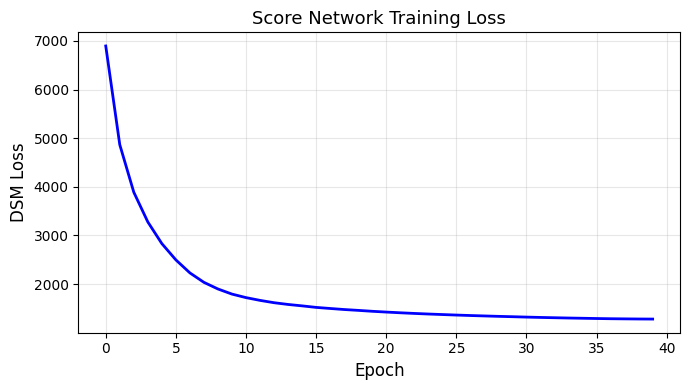

In [40]:
# Training loss plot
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(dsm_losses, 'b-', linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('DSM Loss', fontsize=12)
ax.set_title('Score Network Training Loss', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [41]:
@torch.no_grad()
def langevin_dynamics(score_model, n=16, T=2000, eta=5e-5):
    score_model.eval()
    x = torch.randn(n, 784, device=device)
    for t in range(T):
        score = score_model(x)
        x     = x + eta * score + (2*eta)**0.5 * torch.randn_like(x)
        if t % 500 == 499:
            x = x.clamp(-0.5, 1.5)
    return x.clamp(0, 1)


print('Running Langevin dynamics (T=2000 steps)...')
samples = langevin_dynamics(score_net, n=16, T=2000, eta=5e-5)
samples_np = samples.cpu().numpy()
print(f'Generated {samples_np.shape[0]} samples.')


Running Langevin dynamics (T=2000 steps)...
Generated 16 samples.


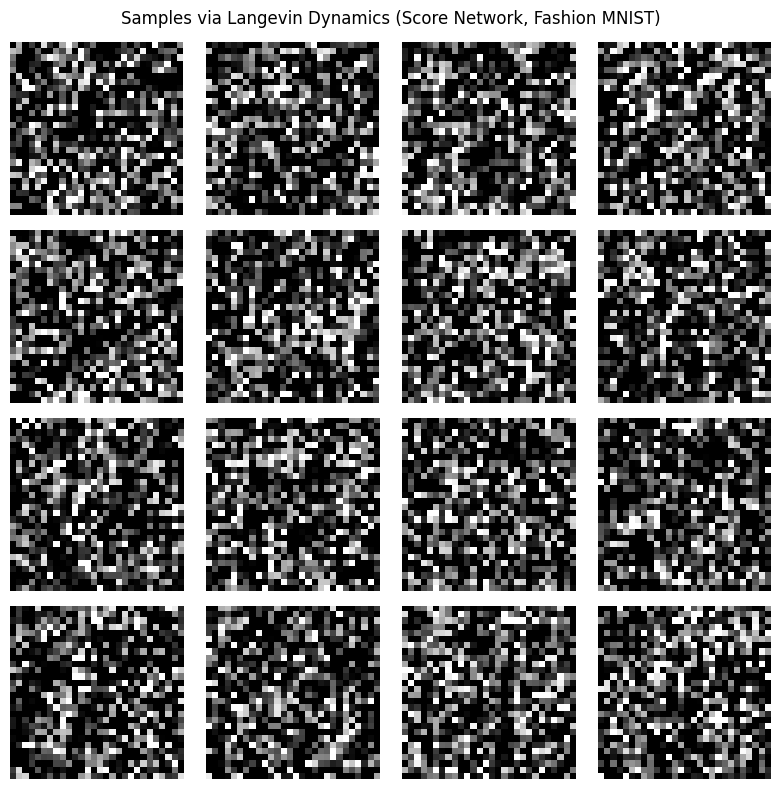

In [42]:
# Visualise Generated Samples
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples_np[i].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
    ax.axis('off')
plt.suptitle('Samples via Langevin Dynamics (Score Network, Fashion MNIST)', fontsize=12)
plt.tight_layout()
plt.show()


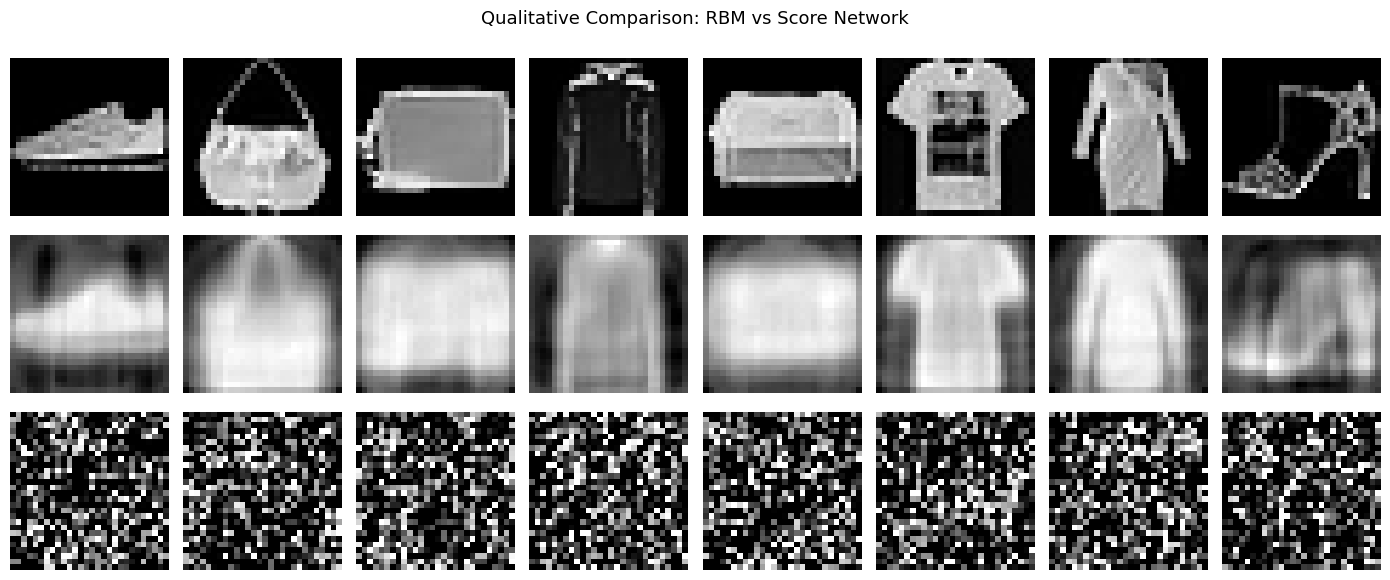

In [43]:
# Side-by-side comparison: RBM reconstructions vs Score Network (Langevin) samples
rng = np.random.default_rng(2)
idxs = rng.choice(len(Fv_test), 8, replace=False)
v_orig_cmp = Fv_test[idxs].to(device)
v_rbm_rec  = rbm_results[100]['rbm'].reconstruct(v_orig_cmp).cpu().detach().numpy()

# Take first 8 Langevin samples already generated
lg_samples = samples_np[:8]

fig, axes = plt.subplots(3, 8, figsize=(14, 6))
for i in range(8):
    axes[0, i].imshow(v_orig_cmp[i].cpu().numpy().reshape(28, 28), cmap='gray'); axes[0, i].axis('off')
    axes[1, i].imshow(v_rbm_rec[i].reshape(28, 28),                cmap='gray'); axes[1, i].axis('off')
    axes[2, i].imshow(lg_samples[i].reshape(28, 28),               cmap='gray'); axes[2, i].axis('off')
axes[0, 0].set_ylabel('Original',      fontsize=9)
axes[1, 0].set_ylabel('RBM (m=100)',   fontsize=9)
axes[2, 0].set_ylabel('Score+Langevin',fontsize=9)
plt.suptitle('Qualitative Comparison: RBM vs Score Network', fontsize=13)
plt.tight_layout()
plt.show()

### Discussion: Effect of Step Size η and Number of Steps T on Langevin Dynamics

The Langevin update is $x_{t+1} = x_t + \eta \, s_\theta(x_t) + \sqrt{2\eta}\,\xi_t$, where $\xi_t \sim \mathcal{N}(0,I)$.

**Effect of step size η:**
- **Too large η** (e.g., η > 1e-3 for this setting): the gradient ascent step overshoots high-density regions. The injected noise $\sqrt{2\eta}\,\xi_t$ also becomes large, causing the chain to diverge or produce very noisy, incoherent samples.
- **Too small η** (e.g., η < 1e-6): the chain mixes extremely slowly — each step barely moves, so many more iterations are needed to traverse the distribution. Samples will look like slightly perturbed noise initializations rather than realistic images.
- **Well-chosen η** (here η = 5×10⁻⁵): balances drift toward high-density regions with sufficient exploration noise, producing recognisable fashion items.

**Effect of number of steps T:**
- **Too few steps** (e.g., T < 100): the chain has not mixed from the $\mathcal{N}(0,I)$ initialization. Samples remain close to Gaussian noise, bearing little resemblance to Fashion MNIST images.
- **Sufficient steps** (T = 2000 here): the chain has had time to follow the score field toward modes of the learned distribution, producing sharper, more structured samples.
- **Very many steps** (T >> 10000): if the score network is imperfect (as here, trained with finite data and a fixed σ), samples may drift to degenerate solutions or become overly smooth; also computationally expensive.

**Comparison with RBM:**
- **RBM** (m=100) produces sharp reconstructions when given a real input image (one Gibbs step), but is not well-suited for unconditional generation from noise, as Gaussian visible units and limited hidden capacity make pure Gibbs sampling blurry.
- **Score Network + Langevin** generates samples unconditionally from Gaussian noise $x_0 \sim \mathcal{N}(0,I)$. With a moderately trained MLP score network (40 epochs, fixed σ=0.3) and T=2000 Langevin steps, the generated samples exhibit rough foreground/background contrast but lack the sharpness of RBM reconstructions (which start from a real image). The limited sample quality is expected: a single fixed noise level cannot capture the full data distribution as effectively as annealed multi-scale methods (e.g., NCSN). Longer training, larger T, or a noise-annealing schedule would substantially improve generation quality.